# Variogram models & estimators

The variogram is the heart of kriging: it encodes *how fast the field de-correlates with distance*. This notebook
is a tour of the **theoretical models** geostatista ships, the two **empirical estimators**, and how to **choose a
model** with cross-validation. See the [kriging workflow](01_kriging_workflow.ipynb) for the end-to-end pipeline.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from geostatista import models

print("bounded (fittable) models :", sorted(models.BOUNDED_MODELS))
print("all model functions       :", sorted(models.MODELS))

2026-07-18 20:19:09 | INFO | pyramids.base.config | Logging is configured.


bounded (fittable) models : ['exponential', 'gaussian', 'matern', 'spherical']
all model functions       : ['exponential', 'gaussian', 'matern', 'nugget', 'power', 'spherical']


## 1. The bounded models

Every bounded model is `gamma(h; nugget, sill, range)`: it starts at the **nugget** (a micro-scale discontinuity
at `h -> 0+`), rises with lag `h`, and levels off at the **sill**. They differ in shape:

- **spherical** reaches the sill *exactly* at the range;
- **exponential** approaches it asymptotically (practical range at `h = range`);
- **gaussian** is smooth and parabolic near the origin — good for very continuous fields;
- **matern** adds a smoothness parameter `nu` (here 1.5).

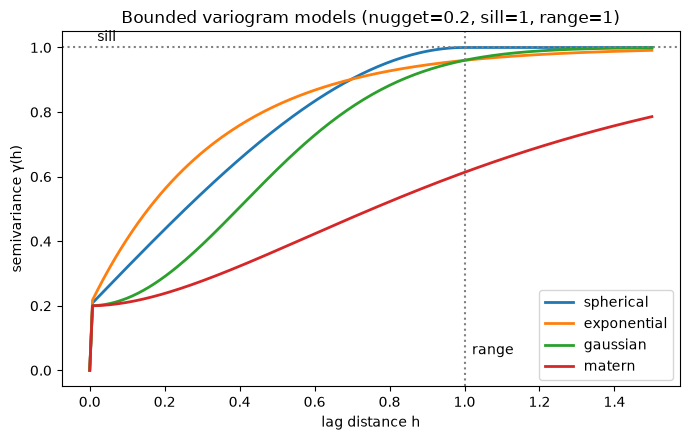

In [2]:
h = np.linspace(0.0, 1.5, 200)
nugget, sill, rng = 0.2, 1.0, 1.0

fig, ax = plt.subplots(figsize=(7, 4.5))
for name in ["spherical", "exponential", "gaussian", "matern"]:
    ax.plot(h, models.MODELS[name](h, nugget, sill, rng), label=name, lw=2)
ax.axhline(sill, ls=":", c="grey"); ax.axvline(rng, ls=":", c="grey")
ax.text(0.02, sill + 0.02, "sill"); ax.text(rng + 0.02, 0.05, "range")
ax.set_xlabel("lag distance h"); ax.set_ylabel("semivariance γ(h)")
ax.set_title("Bounded variogram models (nugget=0.2, sill=1, range=1)")
ax.legend(); fig.tight_layout()

## 2. The unbounded and pure-nugget models

Two more model functions are available (as functions, not as fittable models, because they have a different
parameterization):

- **power** — `gamma(h) = nugget + scale · h^exponent` with `0 < exponent < 2`: unbounded, for non-stationary
  fields with no sill;
- **nugget** — a flat `gamma(h) = nugget` for all `h > 0`: pure noise, no spatial structure.

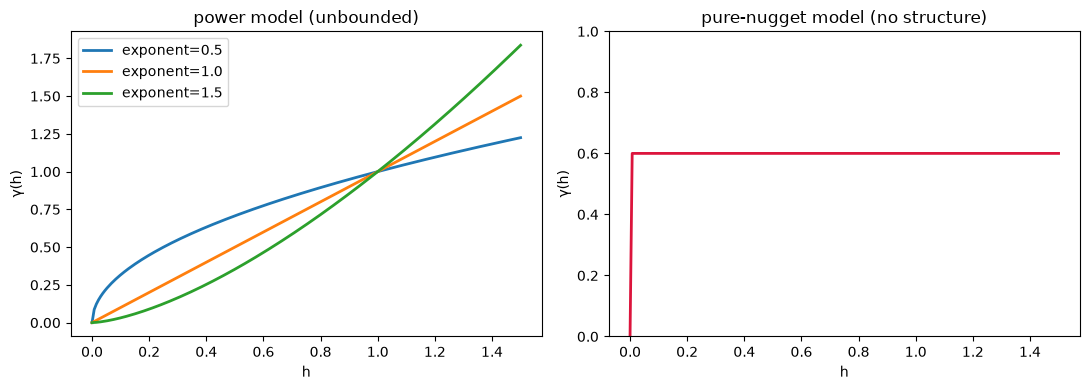

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for e in (0.5, 1.0, 1.5):
    ax[0].plot(h, models.power(h, 0.0, 1.0, e), label=f"exponent={e}", lw=2)
ax[0].set_title("power model (unbounded)"); ax[0].set_xlabel("h"); ax[0].set_ylabel("γ(h)"); ax[0].legend()

ax[1].plot(h, models.nugget(h, 0.6), lw=2, c="crimson")
ax[1].set_title("pure-nugget model (no structure)"); ax[1].set_xlabel("h"); ax[1].set_ylabel("γ(h)")
ax[1].set_ylim(0, 1.0)
fig.tight_layout()

## 3. Matheron vs Cressie estimators

The **empirical** variogram can be estimated two ways. The classic **Matheron** estimator averages squared
differences; the **Cressie** estimator is a robust alternative that down-weights outliers. On clean data they
agree; add a wild outlier and Matheron's cloud inflates while Cressie stays put.

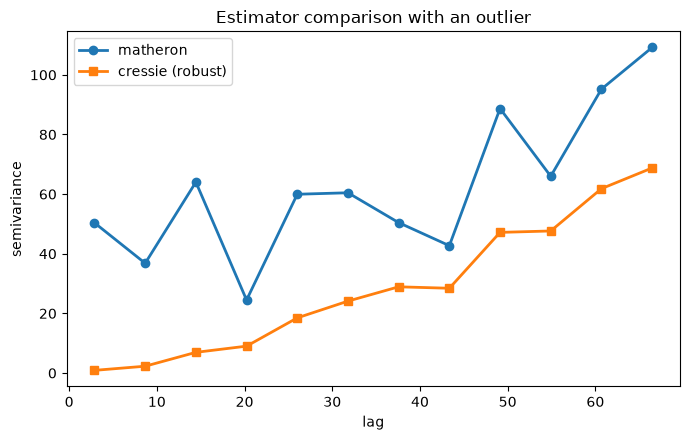

In [4]:
import geopandas as gpd
from shapely.geometry import Point
from geostatista import Samples

rng_ = np.random.default_rng(1)
xy = rng_.uniform(0.0, 100.0, (90, 2))
field = np.sin(xy[:, 0] / 20.0) * 8.0 + 20.0
field[0] += 60.0                         # inject one gross outlier
gdf = gpd.GeoDataFrame({"z": field}, geometry=[Point(*p) for p in xy], crs="EPSG:32633")
samples = Samples(gdf)

matheron = samples.variogram("z", n_lags=12, estimator="matheron").to_dataframe()
cressie = samples.variogram("z", n_lags=12, estimator="cressie").to_dataframe()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(matheron["lag"], matheron["semivariance"], "o-", label="matheron", lw=2)
ax.plot(cressie["lag"], cressie["semivariance"], "s-", label="cressie (robust)", lw=2)
ax.set_xlabel("lag"); ax.set_ylabel("semivariance"); ax.set_title("Estimator comparison with an outlier")
ax.legend(); fig.tight_layout()

## 4. Choosing a model with cross-validation

Don't eyeball it — fit each candidate and let **leave-one-out cross-validation** rank them. The best model
minimizes RMSE while keeping the standardized RMSE near 1 (honest uncertainty). We reuse a clean field here.

In [5]:
clean = np.sin(xy[:, 0] / 20.0) * np.cos(xy[:, 1] / 20.0) * 8.0 + 20.0
gdf2 = gpd.GeoDataFrame({"z": clean}, geometry=[Point(*p) for p in xy], crs="EPSG:32633")
s2 = Samples(gdf2)

rows = []
for name in ["spherical", "exponential", "gaussian", "matern"]:
    vg = s2.variogram("z").fit(model=name)
    summary = s2.cross_validate("z", vg, n_neighbors=None).attrs["summary"]
    rows.append((name, round(vg.nugget, 3), round(vg.sill, 2), round(vg.range_, 1),
                 round(summary["RMSE"], 4), round(summary["RMSE_standardized"], 3)))

import pandas as pd
pd.DataFrame(rows, columns=["model", "nugget", "sill", "range", "RMSE", "RMSE_std"]).set_index("model")

,nugget,sill,range,RMSE,RMSE_std
model,,,,,
spherical,0.0,17.55,62.4,0.3932,0.182
exponential,0.0,25.54,151.4,0.5480,0.237
gaussian,0.0,17.57,49.0,0.0196,0.230
matern,0.0,19.26,25.3,0.2655,0.184


## 5. When a fit is impossible — `VariogramFitError`

If the field has no spatial structure to fit (e.g. a constant column), fitting raises a clear
`VariogramFitError` rather than returning garbage. Catch it and fall back (e.g. to IDW).

In [6]:
from geostatista import VariogramFitError

flat = gpd.GeoDataFrame({"z": np.full(len(xy), 5.0)}, geometry=[Point(*p) for p in xy], crs="EPSG:32633")
try:
    Samples(flat).variogram("z").fit(model="spherical")
except VariogramFitError as exc:
    print("caught VariogramFitError:", exc)

caught VariogramFitError: fit: the empirical semivariance is zero everywhere (constant field) — cannot fit


**Takeaways:** pick `spherical`/`exponential` for most fields, `gaussian` for very smooth ones, `matern` when you
want to tune smoothness; use the `cressie` estimator when outliers are a concern; and always let cross-validation
arbitrate. Back to the [kriging workflow](01_kriging_workflow.ipynb).